# Fire-Spread Explorer

Simulate wildfire propagation with **pyretechnics**, fed by **Google Earth Engine** data (US).

All logic lives in the `firesim` package. **You only edit the scenario cell below** — set the
area of interest, ignition point, ignition date, and projection period, then run the notebook.

| Layer | Source |
| --- | --- |
| Slope / aspect | `USGS/SRTMGL1_003` (SRTM DEM) |
| Fuel model | `USGS/NLCD_RELEASES/2019_REL/NLCD/2019` land cover -> Scott & Burgan 40 |
| Wind, temperature, 100 hr dead FM | `IDAHO_EPSCOR/GRIDMET` |
| 1 hr / 10 hr dead FM | Simard EMC from GRIDMET |
| Live fuel moisture, canopy | seasonal constants (surface-fire MVP) |

> MVP: surface fire only (canopy = 0), live moisture as constants, historical weather via GRIDMET.
> See `docs/pyretechnics_weathernext3_inputs.md` for the full source analysis and upgrade paths.

In [1]:
# Make the firesim package importable regardless of the notebook's working directory.
import pathlib
import sys

root = pathlib.Path.cwd()
if not (root / "firesim").exists():
    root = root.parent
sys.path.insert(0, str(root))

from firesim import SimulationConfig, run, viz

## 1. Define your scenario

Edit the values below. `aoi_bounds` is `(west, south, east, north)` in lon/lat, and the
ignition point must fall inside it. Use a **historical** date (GRIDMET coverage, 1979-present).

In [2]:
config = SimulationConfig(
    aoi_bounds=(-120.55, 39.00, -120.30, 39.20),  # (west, south, east, north)
    ignition_lonlat=(-120.45, 39.10),             # (lon, lat) fire departure
    ignition_date="2024-08-15",                   # YYYY-MM-DD (historical)
    projection_days=7,                             # projection horizon
    weather_source="gridmet",                      # this notebook uses GRIDMET
)
config

SimulationConfig(aoi_bounds=(-120.55, 39.0, -120.3, 39.2), ignition_lonlat=(-120.45, 39.1), ignition_date='2024-08-15', projection_days=7, weather_source='gridmet', weathernext_stat='mean', weathernext_step_hours=6, weathernext_init_time=None, allow_gridmet_fallback=True, constrain_to_land=True, water_fraction_threshold=0.25, water_buffer_cells=2, start_hour=12, max_pixels=160, min_scale_m=30.0, live_herbaceous=0.9, live_woody=0.6, foliar=1.0, canopy_cover=0.0, canopy_height=0.0, canopy_base_height=0.0, canopy_bulk_density=0.0)

## 2. Run the simulation

Fetches all Earth Engine layers and runs the spread engine. The first run triggers an Earth
Engine authentication prompt for your `EE_PROJECT` (set in `.env`).

In [3]:
results = run(config)
results["stats"]

{'burned_cells': 3278,
 'burned_hectares': 6258.465978875176,
 'burned_acres': 15464.982357099503,
 'max_flame_length_m': 1.7762162685394287,
 'mean_spread_rate_m_min': 0.8693835735321045,
 'stop_condition': 'max duration reached',
 'cell_size_m': 138.17500000000194}

## 3. Explore the fire on an interactive map

Toggle the arrival-day overlay and daily perimeters in the layer control (top-right).


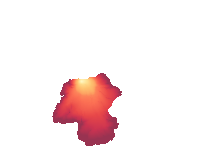
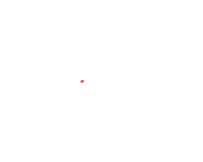
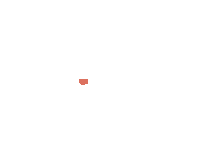
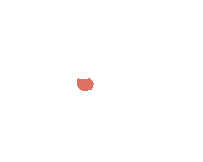
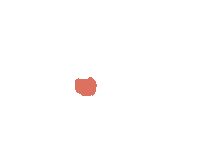
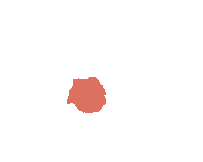
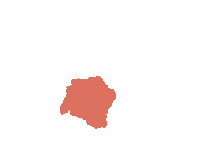
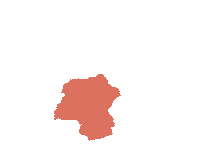

In [4]:
viz.build_map(config, results)

## 4. Charts

Cumulative burned area over time, flame-length distribution, and spread rate over time.

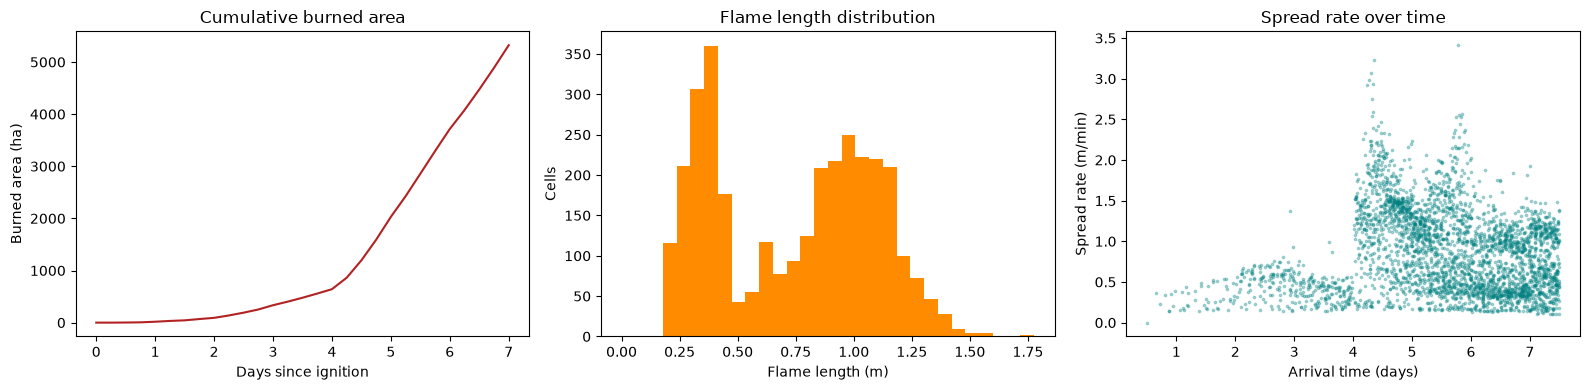

In [5]:
viz.plot_charts(config, results);